In [5]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
from nilearn import image as nimg
from nilearn import plotting as nplot
import bids
from nltools.file_reader import onsets_to_dm
from nltools.stats import regress, zscore
from nltools.data import Brain_Data, Design_Matrix
from nltools.stats import find_spikes 
from nilearn.plotting import view_img, glass_brain, plot_stat_map
from bids import BIDSLayout, BIDSValidator
import os
from pathlib import Path
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix
from nilearn.glm.first_level import FirstLevelModel
from nilearn import plotting
from nilearn.plotting import plot_contrast_matrix
from nilearn.glm.first_level import FirstLevelModel
from nilearn import plotting
# creating mean img for plotting purposes 
from nilearn.image import mean_img
from nilearn.image import load_img
from nibabel import load
from nibabel.gifti import GiftiDataArray, GiftiImage
from nilearn.glm.first_level import run_glm as run_glm
from nilearn.glm import compute_contrast
import nilearn
fsaverage = nilearn.datasets.fetch_surf_fsaverage(mesh='fsaverage')

# Making results folder -- change to what this should actually be 
path = '/Volumes/drive/AVP-BDD/'
os.chdir(path)


[fetch_surf_fsaverage] Dataset found in /Users/gilliangrennan/nilearn_data/fsaverage


In [7]:
layout = bids.BIDSLayout('/Volumes/drive/AVP-BDD/derivatives', validate=False,
                  config=['bids','derivatives'])
print(layout)
subjects = layout.get_subjects()

def load_bids_events(layout,onsets, subject, task, run):
    '''Create a design_matrix instance from BIDS event file'''
    
    tr = 1
    # change lines below -- can change to "mask", change task to "self-other"
    func_files = layout.get(subject=subject,
                        datatype='func', task=task,
                        desc='preproc',
                        space='MNI152NLin2009cAsym',
                        extension='nii.gz',
                       return_type='file')
    func_file = nimg.load_img(func_files[run])
    n_tr = func_file.shape[-1]
    onsets=onsets[run]
    #onsets = pd.read_csv(layout_raw.get(subject=subject, suffix='events')[run].path, sep='\t') -- line to use if events changes by 
    
    # line below is isolating the onset, duration, and trial type columns -- change according to events.tsv format 
    onsets_actual = onsets.iloc[:, [1,4,3]]
    onsets_actual.columns = ['onset', 'duration','trial_type'] # make sure this order matches with what's loaded in as "onsets_actua
    sampling_freq = 1/tr
    n_scans=n_tr
    return onsets_actual, tr, n_scans


def create_high_events_file(file_path):
    data = pd.read_csv(file_path)  # Adjust delimiter if necessary

    # Define category mapping
    condition_mapping = {
        "LSF": "LSF", "NSF": "NSF", "HSF": "HSF"
    }

    data["Condition"] = data["Condition"].map(condition_mapping)

    # Extract unique blocks
    block_summary = data.groupby("Block").agg({
        "Stimulus Onset (s)": "first",
        "Stimulus Offset (s)": "last",
        "Condition": "first"
    }).reset_index()

    # Rename columns for clarity
    block_summary.rename(columns={
        "Stimulus Onset (s)": "onset",
        "Stimulus Offset (s)": "block_end",
        "Condition": "trial_type"
    }, inplace=True)
    
    block_summary["duration"] = block_summary["block_end"]-block_summary["onset"]
    block_summary["onset"] = np.round(block_summary["onset"])
    block_summary["duration"] = np.round(block_summary["duration"])

    # Save the processed data
    output_path = "/Volumes/drive/AVP-BDD/derivatives/events.csv"
    block_summary.to_csv(output_path, index=False)
    return block_summary



BIDS Layout: ...umes/drive/AVP-BDD/derivatives | Subjects: 59 | Sessions: 59 | Runs: 177


In [8]:
subjects = layout.get_subjects()
subjects = sorted(subjects)

print(f"Found {len(subjects)} subjects: {subjects}")


Found 59 subjects: ['102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '201', '202', '204', '205', '206', '207', '208', '209', '210', '211', '212', '213', '214', '215', '216', '217', '218', '219', '220', '221', '222', '223', '224', '225', '226', '227', '228', '229', '230']


In [4]:
from nilearn.maskers import NiftiLabelsMasker
from nilearn.maskers import NiftiMasker
import numpy as np
import pandas as pd
import os
from nilearn.image import math_img

# -----------------------------
# Subjects to analyze
# -----------------------------
runs = ['1', '2', '3']
task = 'SFhigh'
categories = ['Face', 'Body', 'House']

hrf_model = "spm"
high_pass = 0.01

# Quality control thresholds
fd_threshold = 0.5  # mm
accuracy_threshold = 0.70  # 70% minimum accuracy

# Optional: store results
all_subject_results = {}

# Track FD scrubbing across all subjects
fd_summary = {
    'subject': [],
    'total_frames': [],
    'scrubbed_frames': [],
    'pct_scrubbed': []
}

# Track behavioral performance
behavioral_summary = {
    'subject': [],
    'run': [],
    'category': [],
    'n_oddballs': [],
    'n_responses': [],
    'accuracy': [],
    'excluded': []
}

# Track category-run mapping
category_run_mapping = {}

for sub in subjects:
    print(f"\n===== Running subject {sub} =====")

    # --------------------------------------------------
    # Subject-specific V1 mask
    # --------------------------------------------------
    v1_mask = f"/Volumes/drive/AVP-BDD/freesurfer/sub-{sub}/mri/benson2025_varea.nii.gz"

    if not os.path.exists(v1_mask):
        print(f"V1 mask not found for subject {sub}, skipping.")
        continue

    v1_binary_mask = math_img("img == 2", img=v1_mask)

    masker = NiftiMasker(
        mask_img=v1_binary_mask,
        standardize=False
    )

    # --------------------------------------------------
    # Determine category-run mapping for this subject
    # --------------------------------------------------
    print("\n  Determining category-run mapping...")
    run_category_map = {}  # run -> category
    category_run_map = {}  # category -> run
    
    for run in runs:
        for category in categories:
            file_path = (
                f"/Volumes/drive/AVP-BDD/behavior/"
                f"{sub}/high-level/Subject_{sub}_Run_{run}_{category}_RT.csv"
            )
            
            if os.path.exists(file_path):
                run_category_map[run] = category
                category_run_map[category] = run
                print(f"    Run {run}: {category}")
                break
    
    # Store mapping for this subject
    category_run_mapping[sub] = {
        'run_to_category': run_category_map,
        'category_to_run': category_run_map
    }
    
    if len(run_category_map) != 3:
        print(f"  Warning: Could not find all 3 category files for subject {sub}")
        print(f"  Found: {run_category_map}")

    # --------------------------------------------------
    # Check behavioral performance for each run
    # --------------------------------------------------
    print("\n  Checking behavioral performance...")
    runs_to_include = []
    runs_to_include_indices = []  # Store original indices
    runs_to_include_categories = []  # Store categories for included runs
    
    for run_idx, run in enumerate(runs):
        if run not in run_category_map:
            print(f"  Run {run}: No behavioral file found, skipping run.")
            behavioral_summary['subject'].append(sub)
            behavioral_summary['run'].append(run)
            behavioral_summary['category'].append(np.nan)
            behavioral_summary['n_oddballs'].append(np.nan)
            behavioral_summary['n_responses'].append(np.nan)
            behavioral_summary['accuracy'].append(np.nan)
            behavioral_summary['excluded'].append(True)
            continue
        
        category = run_category_map[run]
        file_path = (
            f"/Volumes/drive/AVP-BDD/behavior/"
            f"{sub}/high-level/Subject_{sub}_Run_{run}_{category}_RT.csv"
        )
        
        # Load behavioral data
        behav_df = pd.read_csv(file_path)
        
        # Count oddballs (True values)
        n_oddballs = (behav_df['Oddball'] == True).sum()
        
        # Count responses (non-null reaction times)
        n_responses = behav_df['Reaction Time (s)'].notna().sum()
        
        # Calculate accuracy
        accuracy = n_responses / n_oddballs if n_oddballs > 0 else 0
        
        # Determine if run should be included
        include_run = accuracy >= accuracy_threshold
        
        # Store behavioral data
        behavioral_summary['subject'].append(sub)
        behavioral_summary['run'].append(run)
        behavioral_summary['category'].append(category)
        behavioral_summary['n_oddballs'].append(n_oddballs)
        behavioral_summary['n_responses'].append(n_responses)
        behavioral_summary['accuracy'].append(accuracy)
        behavioral_summary['excluded'].append(not include_run)
        
        if include_run:
            runs_to_include.append(run)
            runs_to_include_indices.append(run_idx)
            runs_to_include_categories.append(category)
            print(f"  Run {run} ({category}): {n_responses}/{n_oddballs} oddballs detected ({accuracy*100:.1f}%) - INCLUDED")
        else:
            print(f"  Run {run} ({category}): {n_responses}/{n_oddballs} oddballs detected ({accuracy*100:.1f}%) - EXCLUDED (below {accuracy_threshold*100}%)")
    
    # Check if subject has any valid runs
    if len(runs_to_include) == 0:
        print(f"  Subject {sub} has no runs meeting accuracy threshold, skipping subject.")
        continue
    
    print(f"  Including {len(runs_to_include)}/{len(runs)} runs for analysis")

    # --------------------------------------------------
    # Load events (onsets) - only for included runs
    # --------------------------------------------------
    onsets = []
    for run, category in zip(runs_to_include, runs_to_include_categories):
        file_path = (
            f"/Volumes/drive/AVP-BDD/behavior/"
            f"{sub}/high-level/Subject_{sub}_Run_{run}_{category}_RT.csv"
        )
        onsets_temp = create_high_events_file(file_path)  # Note: using create_high_events_file
        onsets.append(onsets_temp)

    # --------------------------------------------------
    # Load fMRI images - only for included runs
    # --------------------------------------------------
    all_fmri_imgs = layout.get(
        subject=sub,
        datatype='func',
        task=task,
        desc='preproc',
        space='T1w',
        extension='nii.gz',
        return_type='file'
    )
    
    # Filter to only included runs using original indices
    fmri_imgs = [all_fmri_imgs[idx] for idx in runs_to_include_indices]

    # Extract ROI time series
    time_series = []
    for con_img in fmri_imgs:
        time_series.append(masker.fit_transform(con_img))
    time_series = np.concatenate(time_series, axis=0)

    # --------------------------------------------------
    # Confounds + Framewise Displacement
    # --------------------------------------------------
    all_confound_files = layout.get(
        subject=sub,
        datatype='func',
        task=task,
        desc='confounds',
        extension="tsv",
        return_type='file'
    )
    
    # Filter to only included runs using original indices
    confound_files = [all_confound_files[idx] for idx in runs_to_include_indices]

    confound_vars = [
        'trans_x','trans_x_derivative1','trans_x_derivative1_power2','trans_x_power2',
        'trans_y','trans_y_derivative1','trans_y_derivative1_power2','trans_y_power2',
        'trans_z','trans_z_derivative1','trans_z_derivative1_power2','trans_z_power2',
        'rot_x','rot_x_derivative1','rot_x_derivative1_power2','rot_x_power2',
        'rot_y','rot_y_derivative1','rot_y_derivative1_power2','rot_y_power2',
        'rot_z','rot_z_derivative1','rot_z_derivative1_power2','rot_z_power2',
        'csf','csf_derivative1','csf_derivative1_power2','csf_power2',
        'white_matter','white_matter_derivative1',
        'white_matter_derivative1_power2','white_matter_power2'
    ]

# --------------------------------------------------
    # Design matrices (per run) + FD scrubbing
    # --------------------------------------------------
    design_matrices = []
    all_fd_scrub = []  # Track FD scrubbing across runs

    for idx, (img, onset_events, category) in enumerate(zip(fmri_imgs, onsets, runs_to_include_categories)):
        # Use the onset events directly from the filtered list
        events, tr, n_scans = load_bids_events(layout, [onset_events], sub, task, 0)
        frame_times = np.arange(n_scans) * tr

        # Load confounds
        confound_df = pd.read_csv(confound_files[idx], sep='\t')
        
        # Calculate or load FD
        if 'framewise_displacement' in confound_df.columns:
            fd = confound_df['framewise_displacement'].values
        else:
            # Calculate FD manually if not in confounds file
            fd = np.zeros(len(confound_df))
            if len(confound_df) > 1:
                fd[1:] = (
                    np.abs(confound_df['trans_x'].diff()) +
                    np.abs(confound_df['trans_y'].diff()) +
                    np.abs(confound_df['trans_z'].diff()) +
                    np.abs(confound_df['rot_x'].diff() * 50) +
                    np.abs(confound_df['rot_y'].diff() * 50) +
                    np.abs(confound_df['rot_z'].diff() * 50)
                )
        
        # Create FD scrubbing regressors
        fd_scrub = (fd > fd_threshold).astype(int)
        n_scrubbed = np.sum(fd_scrub)
        print(f"  Run {runs_to_include[idx]} ({category}): {n_scrubbed}/{len(fd)} frames exceed FD threshold ({fd_threshold}mm)")
        
        # Add spike regressors to design matrix
        fd_regressors = np.zeros((n_scans, n_scrubbed))
        if n_scrubbed > 0:
            scrub_indices = np.where(fd_scrub)[0]
            for i, scrub_idx in enumerate(scrub_indices):
                fd_regressors[scrub_idx, i] = 1
        
        # Select confound variables
        confound_df_subset = confound_df[confound_vars].copy()
        confound_df_subset.fillna(0, inplace=True)
        
        # Make design matrix
        design_matrix = make_first_level_design_matrix(
            frame_times,
            events,
            hrf_model=hrf_model,
            drift_model="polynomial",
            drift_order=3,
            add_regs=confound_df_subset,
            add_reg_names=confound_vars,
            high_pass=high_pass,
        )

        design_matrix = design_matrix.iloc[:, :-1]  # remove constant

        # Add FD spike regressors
        if n_scrubbed > 0:
            for i in range(n_scrubbed):
                design_matrix[f'fd_scrub_run{runs_to_include[idx]}_{i}'] = fd_regressors[:, i]
        
        # Run-specific intercepts (only for included runs)
        for run_num in range(len(runs_to_include)):
            design_matrix[f'intercept{run_num+1}'] = int(idx == run_num)
        
        # Create category-specific SF regressors
        # These allow us to test SF effects within each category
        for cat in categories:
            if cat == category:
                # For the current category, copy the SF regressors with category-specific names
                if 'LSF' in design_matrix.columns:
                    design_matrix[f'{cat}_LSF'] = design_matrix['LSF'].values
                if 'NSF' in design_matrix.columns:
                    design_matrix[f'{cat}_NSF'] = design_matrix['NSF'].values
                if 'HSF' in design_matrix.columns:
                    design_matrix[f'{cat}_HSF'] = design_matrix['HSF'].values
            else:
                # For other categories, set to zero (this run doesn't have that category)
                design_matrix[f'{cat}_LSF'] = 0
                design_matrix[f'{cat}_NSF'] = 0
                design_matrix[f'{cat}_HSF'] = 0

        design_matrices.append(design_matrix)
        all_fd_scrub.append(fd_scrub)

    design_matrix_allruns = pd.concat(design_matrices, axis=0, ignore_index=True)
    
    # Check for NaN or Inf in design matrix
    if design_matrix_allruns.isnull().any().any():
        print("  WARNING: Design matrix contains NaN values!")
        print("  Columns with NaN:")
        print(design_matrix_allruns.columns[design_matrix_allruns.isnull().any()].tolist())
        design_matrix_allruns.fillna(0, inplace=True)
    
    if np.isinf(design_matrix_allruns.values).any():
        print("  WARNING: Design matrix contains Inf values!")
        design_matrix_allruns = design_matrix_allruns.replace([np.inf, -np.inf], 0)
    
    # Report total FD scrubbing for this subject
    total_scrubbed = sum([np.sum(fd) for fd in all_fd_scrub])
    total_frames = len(design_matrix_allruns)
    pct_scrubbed = 100 * total_scrubbed / total_frames
    print(f"  Total: {total_scrubbed}/{total_frames} frames scrubbed ({pct_scrubbed:.1f}%)")
    
    # Store FD summary for this subject
    fd_summary['subject'].append(sub)
    fd_summary['total_frames'].append(total_frames)
    fd_summary['scrubbed_frames'].append(total_scrubbed)
    fd_summary['pct_scrubbed'].append(pct_scrubbed)

    # --------------------------------------------------
    # Contrasts
    # --------------------------------------------------
    contrast_matrix = np.eye(design_matrix_allruns.shape[1])
    basic_contrasts = {
        column: contrast_matrix[i]
        for i, column in enumerate(design_matrix_allruns.columns)
    }

    # Initialize contrasts dictionary
    contrasts = {}
    
    # Main spatial frequency contrasts (collapsed across categories)
    # Sum the category-specific regressors to get ALL trials
    lsf_contrast = np.zeros(len(design_matrix_allruns.columns))
    nsf_contrast = np.zeros(len(design_matrix_allruns.columns))
    hsf_contrast = np.zeros(len(design_matrix_allruns.columns))
    
    for cat in categories:
        if f'{cat}_LSF' in basic_contrasts:
            lsf_contrast += basic_contrasts[f'{cat}_LSF']
        if f'{cat}_NSF' in basic_contrasts:
            nsf_contrast += basic_contrasts[f'{cat}_NSF']
        if f'{cat}_HSF' in basic_contrasts:
            hsf_contrast += basic_contrasts[f'{cat}_HSF']
    
    # Collapsed contrasts (sum across categories to include ALL trials)
    contrasts["LSF"] = lsf_contrast
    contrasts["NSF"] = nsf_contrast
    contrasts["HSF"] = hsf_contrast
    contrasts["high"] = hsf_contrast - nsf_contrast
    contrasts["low"] = lsf_contrast - nsf_contrast
    
    # Category-specific spatial frequency contrasts
    for cat in categories:
        if f'{cat}_LSF' in basic_contrasts:
            contrasts[f"{cat}-LSF"] = basic_contrasts[f'{cat}_LSF']
            contrasts[f"{cat}-NSF"] = basic_contrasts[f'{cat}_NSF']
            contrasts[f"{cat}-HSF"] = basic_contrasts[f'{cat}_HSF']
            contrasts[f"{cat}-high"] = basic_contrasts[f'{cat}_HSF'] - basic_contrasts[f'{cat}_NSF']
            contrasts[f"{cat}-low"] = basic_contrasts[f'{cat}_LSF'] - basic_contrasts[f'{cat}_NSF']
    # --------------------------------------------------
    # GLM
    # --------------------------------------------------
    labels, estimates = run_glm(time_series, design_matrix_allruns.values)

    subject_results = {}

    for contrast_name, contrast_vec in contrasts.items():
        print(f"  computing contrast: {contrast_name}")

        contrast = compute_contrast(labels, estimates, contrast_vec)

        beta_vox = contrast.effect_size()   # (n_voxels_in_V1,)
        z_vox = contrast.z_score()

        # [Rest of the extraction code remains the same...]
        # -------------------------------------------
        # Peak voxel extraction
        # -------------------------------------------
        # Peak based on absolute z-score (most significant)
        peak_voxel_idx = np.argmax(np.abs(z_vox))
        peak_beta = beta_vox[peak_voxel_idx]
        peak_z = z_vox[peak_voxel_idx]
        
        # Top 10% of voxels by absolute z-score
        n_top_10 = max(1, int(0.1 * len(z_vox)))
        top_10_indices = np.argsort(np.abs(z_vox))[-n_top_10:]
        top_10_beta_mean = np.mean(beta_vox[top_10_indices])
        top_10_z_mean = np.mean(z_vox[top_10_indices])
        
        # Top 20% of voxels by absolute z-score
        n_top_20 = max(1, int(0.2 * len(z_vox)))
        top_20_indices = np.argsort(np.abs(z_vox))[-n_top_20:]
        top_20_beta_mean = np.mean(beta_vox[top_20_indices])
        top_20_z_mean = np.mean(z_vox[top_20_indices])
        
        # Top 10% of POSITIVE voxels only
        positive_mask = beta_vox > 0
        n_positive = np.sum(positive_mask)
        
        if n_positive > 0:
            z_positive = z_vox[positive_mask]
            beta_positive = beta_vox[positive_mask]
            
            # Top 10% of positive voxels
            n_top_10_pos = max(1, int(0.1 * n_positive))
            top_10_pos_indices = np.argsort(z_positive)[-n_top_10_pos:]
            top_10_pos_beta_mean = np.mean(beta_positive[top_10_pos_indices])
            top_10_pos_z_mean = np.mean(z_positive[top_10_pos_indices])
            
            # Top 20% of positive voxels
            n_top_20_pos = max(1, int(0.2 * n_positive))
            top_20_pos_indices = np.argsort(z_positive)[-n_top_20_pos:]
            top_20_pos_beta_mean = np.mean(beta_positive[top_20_pos_indices])
            top_20_pos_z_mean = np.mean(z_positive[top_20_pos_indices])
            
            # Peak positive voxel
            peak_pos_idx = np.argmax(z_positive)
            peak_pos_beta = beta_positive[peak_pos_idx]
            peak_pos_z = z_positive[peak_pos_idx]
        else:
            top_10_pos_beta_mean = np.nan
            top_10_pos_z_mean = np.nan
            top_20_pos_beta_mean = np.nan
            top_20_pos_z_mean = np.nan
            peak_pos_beta = np.nan
            peak_pos_z = np.nan

        # Store results
        subject_results[contrast_name] = {
            # Original metrics
            "beta_vox": beta_vox,
            "z_vox": z_vox,
            "beta_mean": np.mean(beta_vox),
            "beta_median": np.median(beta_vox),
            "z_mean": np.mean(z_vox),
            
            # Peak voxel (any sign)
            "peak_voxel_idx": peak_voxel_idx,
            "peak_beta": peak_beta,
            "peak_z": peak_z,
            
            # Top 10% (any sign)
            "top_10pct_n_voxels": n_top_10,
            "top_10pct_beta_mean": top_10_beta_mean,
            "top_10pct_z_mean": top_10_z_mean,
            
            # Top 20% (any sign)
            "top_20pct_n_voxels": n_top_20,
            "top_20pct_beta_mean": top_20_beta_mean,
            "top_20pct_z_mean": top_20_z_mean,
            
            # Positive voxels only
            "n_positive_voxels": n_positive,
            "pct_positive_voxels": 100 * n_positive / len(beta_vox),
            "peak_pos_beta": peak_pos_beta,
            "peak_pos_z": peak_pos_z,
            
            # Top 10% positive
            "top_10pct_pos_n_voxels": n_top_10_pos if n_positive > 0 else 0,
            "top_10pct_pos_beta_mean": top_10_pos_beta_mean,
            "top_10pct_pos_z_mean": top_10_pos_z_mean,
            
            # Top 20% positive
            "top_20pct_pos_n_voxels": n_top_20_pos if n_positive > 0 else 0,
            "top_20pct_pos_beta_mean": top_20_pos_beta_mean,
            "top_20pct_pos_z_mean": top_20_pos_z_mean,
        }

    all_subject_results[sub] = subject_results


import pickle
import datetime

# Save all_subject_results to disk
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
save_path = f"/Volumes/drive/AVP-BDD/results/high-level/all_subject_results_{timestamp}.pkl"

os.makedirs(os.path.dirname(save_path), exist_ok=True)

with open(save_path, 'wb') as f:
    pickle.dump(all_subject_results, f)

print(f"\nResults saved to: {save_path}")

# Also save the summary dataframes as CSVs for quick inspection
fd_df = pd.DataFrame(fd_summary)
behav_df_summary = pd.DataFrame(behavioral_summary)
fd_df.to_csv(f"/Volumes/drive/AVP-BDD/results/high-level/fd_summary_{timestamp}.csv", index=False)
behav_df_summary.to_csv(f"/Volumes/drive/AVP-BDD/results/high-level/behavioral_summary_{timestamp}.csv", index=False)





===== Running subject 102 =====

  Determining category-run mapping...
    Run 1: House
    Run 2: Face
    Run 3: Body

  Checking behavioral performance...
  Run 1 (House): 27/27 oddballs detected (100.0%) - INCLUDED
  Run 2 (Face): 37/37 oddballs detected (100.0%) - INCLUDED
  Run 3 (Body): 32/32 oddballs detected (100.0%) - INCLUDED
  Including 3/3 runs for analysis


/Volumes/drive/AVP-BDD/codes/.venv/lib/python3.9/site-packages/joblib/memory.py:326: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  return self.func(*args, **kwargs)


[NiftiMasker.wrapped] Resampling images


/Volumes/drive/AVP-BDD/codes/.venv/lib/python3.9/site-packages/joblib/memory.py:326: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  return self.func(*args, **kwargs)


[NiftiMasker.wrapped] Resampling images


...

  Run 2 (Face): 1/335 frames exceed FD threshold (0.5mm)


/var/folders/hq/ms5zk3kj1pd2kwh1bnvtcr0m0000gn/T/ipykernel_3777/2042613332.py:269: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


  Run 3 (House): 0/335 frames exceed FD threshold (0.5mm)
  Columns with NaN:
['fd_scrub_run2_0']
  Total: 1/1005 frames scrubbed (0.1%)


/var/folders/hq/ms5zk3kj1pd2kwh1bnvtcr0m0000gn/T/ipykernel_3777/2042613332.py:269: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


  computing contrast: LSF
  computing contrast: NSF
  computing contrast: HSF
  computing contrast: high
  computing contrast: low
  computing contrast: Face-LSF
  computing contrast: Face-NSF
  computing contrast: Face-HSF
  computing contrast: Face-high
  computing contrast: Face-low
  computing contrast: Body-LSF
  computing contrast: Body-NSF
  computing contrast: Body-HSF
  computing contrast: Body-high
  computing contrast: Body-low
  computing contrast: House-LSF
  computing contrast: House-NSF
  computing contrast: House-HSF
  computing contrast: House-high
  computing contrast: House-low

Results saved to: /Volumes/drive/AVP-BDD/results/high-level/all_subject_results_20260225_110613.pkl


In [3]:
# # --------------------------------------------------
# # Save category-run mapping
# # --------------------------------------------------
# mapping_list = []
# for sub, mapping in category_run_mapping.items():
#     for category, run in mapping['category_to_run'].items():
#         mapping_list.append({
#             'subject': sub,
#             'category': category,
#             'run': run
#         })

# mapping_df = pd.DataFrame(mapping_list)
# mapping_df.to_csv('category_run_mapping.csv', index=False)
# print("\nCategory-run mapping saved to 'category_run_mapping.csv'")

# --------------------------------------------------
# Summary of behavioral performance
# --------------------------------------------------
accuracy_threshold = 0.7
print("\n" + "="*80)
print("BEHAVIORAL PERFORMANCE SUMMARY")
print("="*80)

behav_df = pd.DataFrame(behavioral_summary)

# Per-run summary
print("\nPer-run performance:")
print(behav_df.to_string(index=False))

# Summary statistics
excluded_runs = behav_df['excluded'].sum()
total_runs = len(behav_df)
print("\n" + "-"*80)
print(f"RUNS EXCLUDED DUE TO LOW ACCURACY (<{accuracy_threshold*100}%):")
print(f"  Total runs: {total_runs}")
print(f"  Excluded runs: {excluded_runs}")
print(f"  Percentage excluded: {100*excluded_runs/total_runs:.1f}%")
print(f"  Mean accuracy (all runs): {behav_df['accuracy'].mean()*100:.1f}% (SD={behav_df['accuracy'].std()*100:.1f})")
valid_behav = behav_df[~behav_df['excluded']]
if len(valid_behav) > 0:
    print(f"  Mean accuracy (included runs): {valid_behav['accuracy'].mean()*100:.1f}%")
print("="*80)

# Optional: Save behavioral summary to CSV
behav_df.to_csv('behavioral_performance_summary_highlevel.csv', index=False)
print("\nBehavioral performance summary saved to 'behavioral_performance_summary_highlevel.csv'")

# --------------------------------------------------
# Summary of FD scrubbing across all subjects
# --------------------------------------------------
print("\n" + "="*80)
print("FRAMEWISE DISPLACEMENT SCRUBBING SUMMARY")
print("="*80)

fd_df = pd.DataFrame(fd_summary)

# Per-subject summary
print("\nPer-subject data loss:")
print(fd_df.to_string(index=False))

# Overall summary
total_all_frames = fd_df['total_frames'].sum()
total_all_scrubbed = fd_df['scrubbed_frames'].sum()
overall_pct_scrubbed = 100 * total_all_scrubbed / total_all_frames

print("\n" + "-"*80)
print(f"TOTAL ACROSS ALL SUBJECTS:")
print(f"  Total frames: {total_all_frames}")
print(f"  Scrubbed frames: {total_all_scrubbed}")
print(f"  Percentage scrubbed: {overall_pct_scrubbed:.2f}%")
print(f"  Mean per-subject scrubbing: {fd_df['pct_scrubbed'].mean():.2f}% (SD={fd_df['pct_scrubbed'].std():.2f})")
print(f"  Range: {fd_df['pct_scrubbed'].min():.2f}% - {fd_df['pct_scrubbed'].max():.2f}%")
print("="*80)

# Optional: Save summary to CSV
fd_df.to_csv('fd_scrubbing_summary_highlevel.csv', index=False)
print("\nFD scrubbing summary saved to 'fd_scrubbing_summary_highlevel.csv'")


BEHAVIORAL PERFORMANCE SUMMARY

Per-run performance:
 subject  run category  n_oddballs  n_responses  accuracy  excluded
     102    1    House          27           27  1.000000     False
     102    2     Face          37           37  1.000000     False
     102    3     Body          32           32  1.000000     False
     103    1     Face          34           31  0.911765     False
     103    2    House          38           35  0.921053     False
     103    3     Body          33           32  0.969697     False
     104    1    House          27           25  0.925926     False
     104    2     Body          35           35  1.000000     False
     104    3     Face          38           38  1.000000     False
     105    1    House          29           25  0.862069     False
     105    2     Body          33           29  0.878788     False
     105    3     Face          33           32  0.969697     False
     106    1    House          31           30  0.967742     

In [16]:
### to load in data 
# note: fd_summary and behavioral_summary wont change depending on ROI (V1 vs. V2) 

import pickle
import pandas as pd

# Load results
results_path = "/Volumes/drive/AVP-BDD/results/high-level/V2_all_subject_results_20260225_110613.pkl"
#results_path = "/Volumes/drive/AVP-BDD/results/low-level/V2_all_subject_results_20260224_133823.pkl"

with open(results_path, 'rb') as f:
    all_subject_results = pickle.load(f)

# BEH results
beh_path = "/Volumes/drive/AVP-BDD/results/high-level/behavioral_summary_20260224_131912.csv"
behavioral_summary = pd.read_csv(beh_path)

# FD results
fd_path = "/Volumes/drive/AVP-BDD/results/high-level/fd_summary_20260224_131912.csv"
fd_summary = pd.read_csv(fd_path)

# Access just like before, e.g.:
# all_subject_results['sub-01']['high']['beta_mean']


Group assignments:
  Patients: N=30
  Controls: N=29

EXTRACTING DATA FOR ALL CONTRASTS

Total observations: 1079
Subjects: 56
Unique contrasts: 20

All contrasts data saved to 'all_contrasts_data.csv'

Sample data:
  subject    group contrast_name   category sf_type        beta
0     102  patient           LSF  Collapsed     LSF  107.422655
1     102  patient           NSF  Collapsed     NSF  115.846776
2     102  patient           HSF  Collapsed     HSF  116.328649
3     102  patient          high  Collapsed    high   41.322216
4     102  patient           low  Collapsed     low   58.747883
5     102  patient      Face-LSF       Face     LSF  113.923984
6     102  patient      Face-NSF       Face     NSF   87.121769
7     102  patient      Face-HSF       Face     HSF   95.042547
8     102  patient     Face-high       Face    high   84.441615
9     102  patient      Face-low       Face     low   60.535059

DESCRIPTIVE STATISTICS

Beta values by Group, Category, and SF Type:
         

/var/folders/hq/ms5zk3kj1pd2kwh1bnvtcr0m0000gn/T/ipykernel_6093/418904021.py:273: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  sns.barplot(data=collapsed_diff_data, x='sf_type', y='beta', hue='group',
/var/folders/hq/ms5zk3kj1pd2kwh1bnvtcr0m0000gn/T/ipykernel_6093/418904021.py:278: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['High SF > NSF', 'Low SF > NSF'])
/var/folders/hq/ms5zk3kj1pd2kwh1bnvtcr0m0000gn/T/ipykernel_6093/418904021.py:315: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(['High SF > NSF', 'Low SF > NSF'])


Collapsed contrasts visualization saved as 'group_comparison_collapsed_contrasts.png'


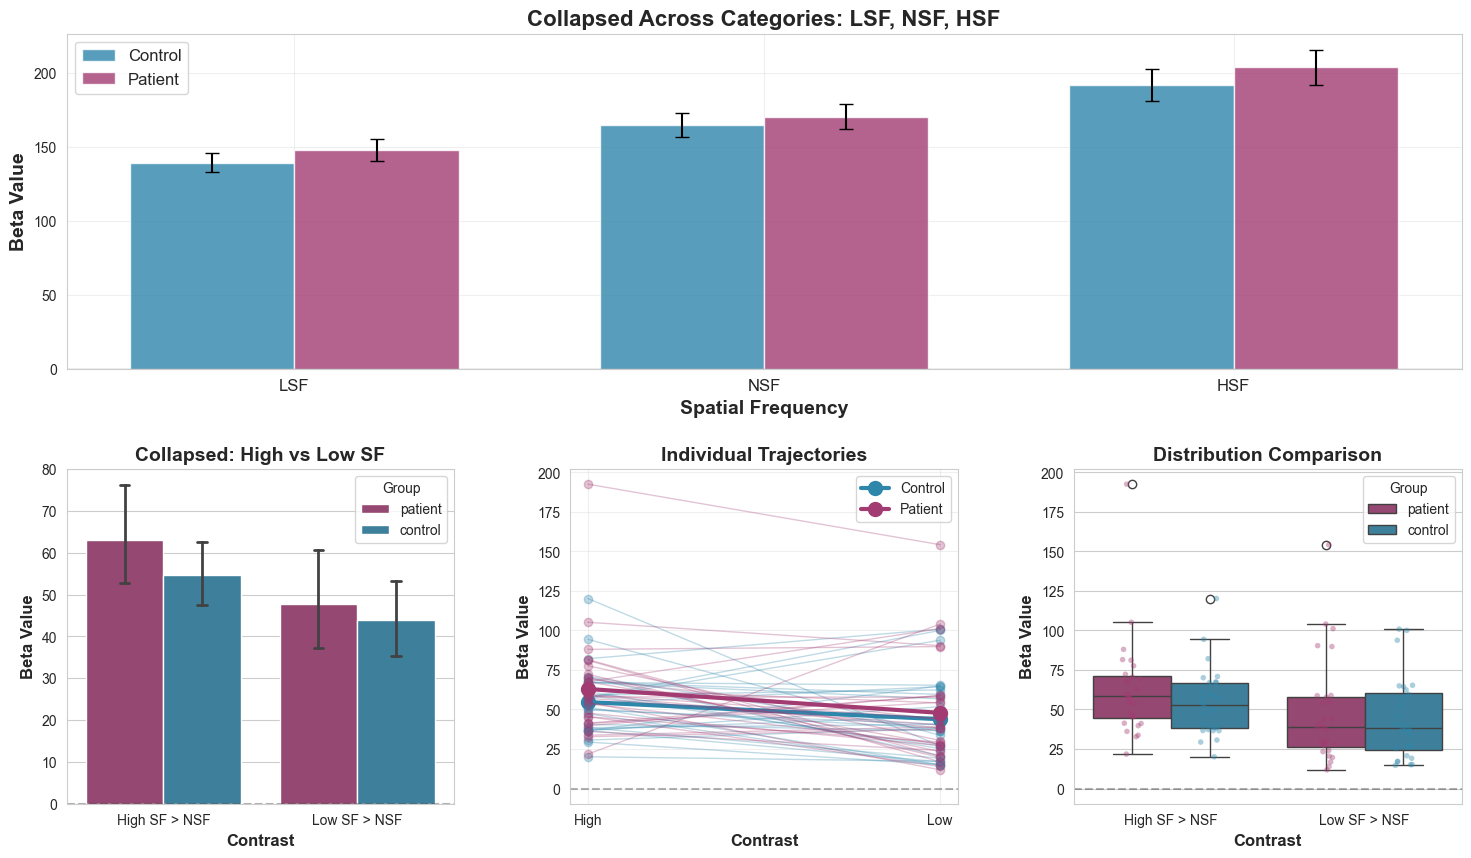

/var/folders/hq/ms5zk3kj1pd2kwh1bnvtcr0m0000gn/T/ipykernel_6093/418904021.py:363: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  sns.barplot(data=cat_diff_data, x='sf_type', y='beta', hue='group',
/var/folders/hq/ms5zk3kj1pd2kwh1bnvtcr0m0000gn/T/ipykernel_6093/418904021.py:368: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['High > NSF', 'Low > NSF'])
/var/folders/hq/ms5zk3kj1pd2kwh1bnvtcr0m0000gn/T/ipykernel_6093/418904021.py:363: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  sns.barplot(data=cat_diff_data, x='sf_type', y='beta', hue='group',
/var/folders/hq/ms5zk3kj1pd2kwh1bnvtcr0m0000gn/T/ipykernel_6093/418904021.py:368: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after s

Category-specific visualization saved as 'group_comparison_category_specific.png'


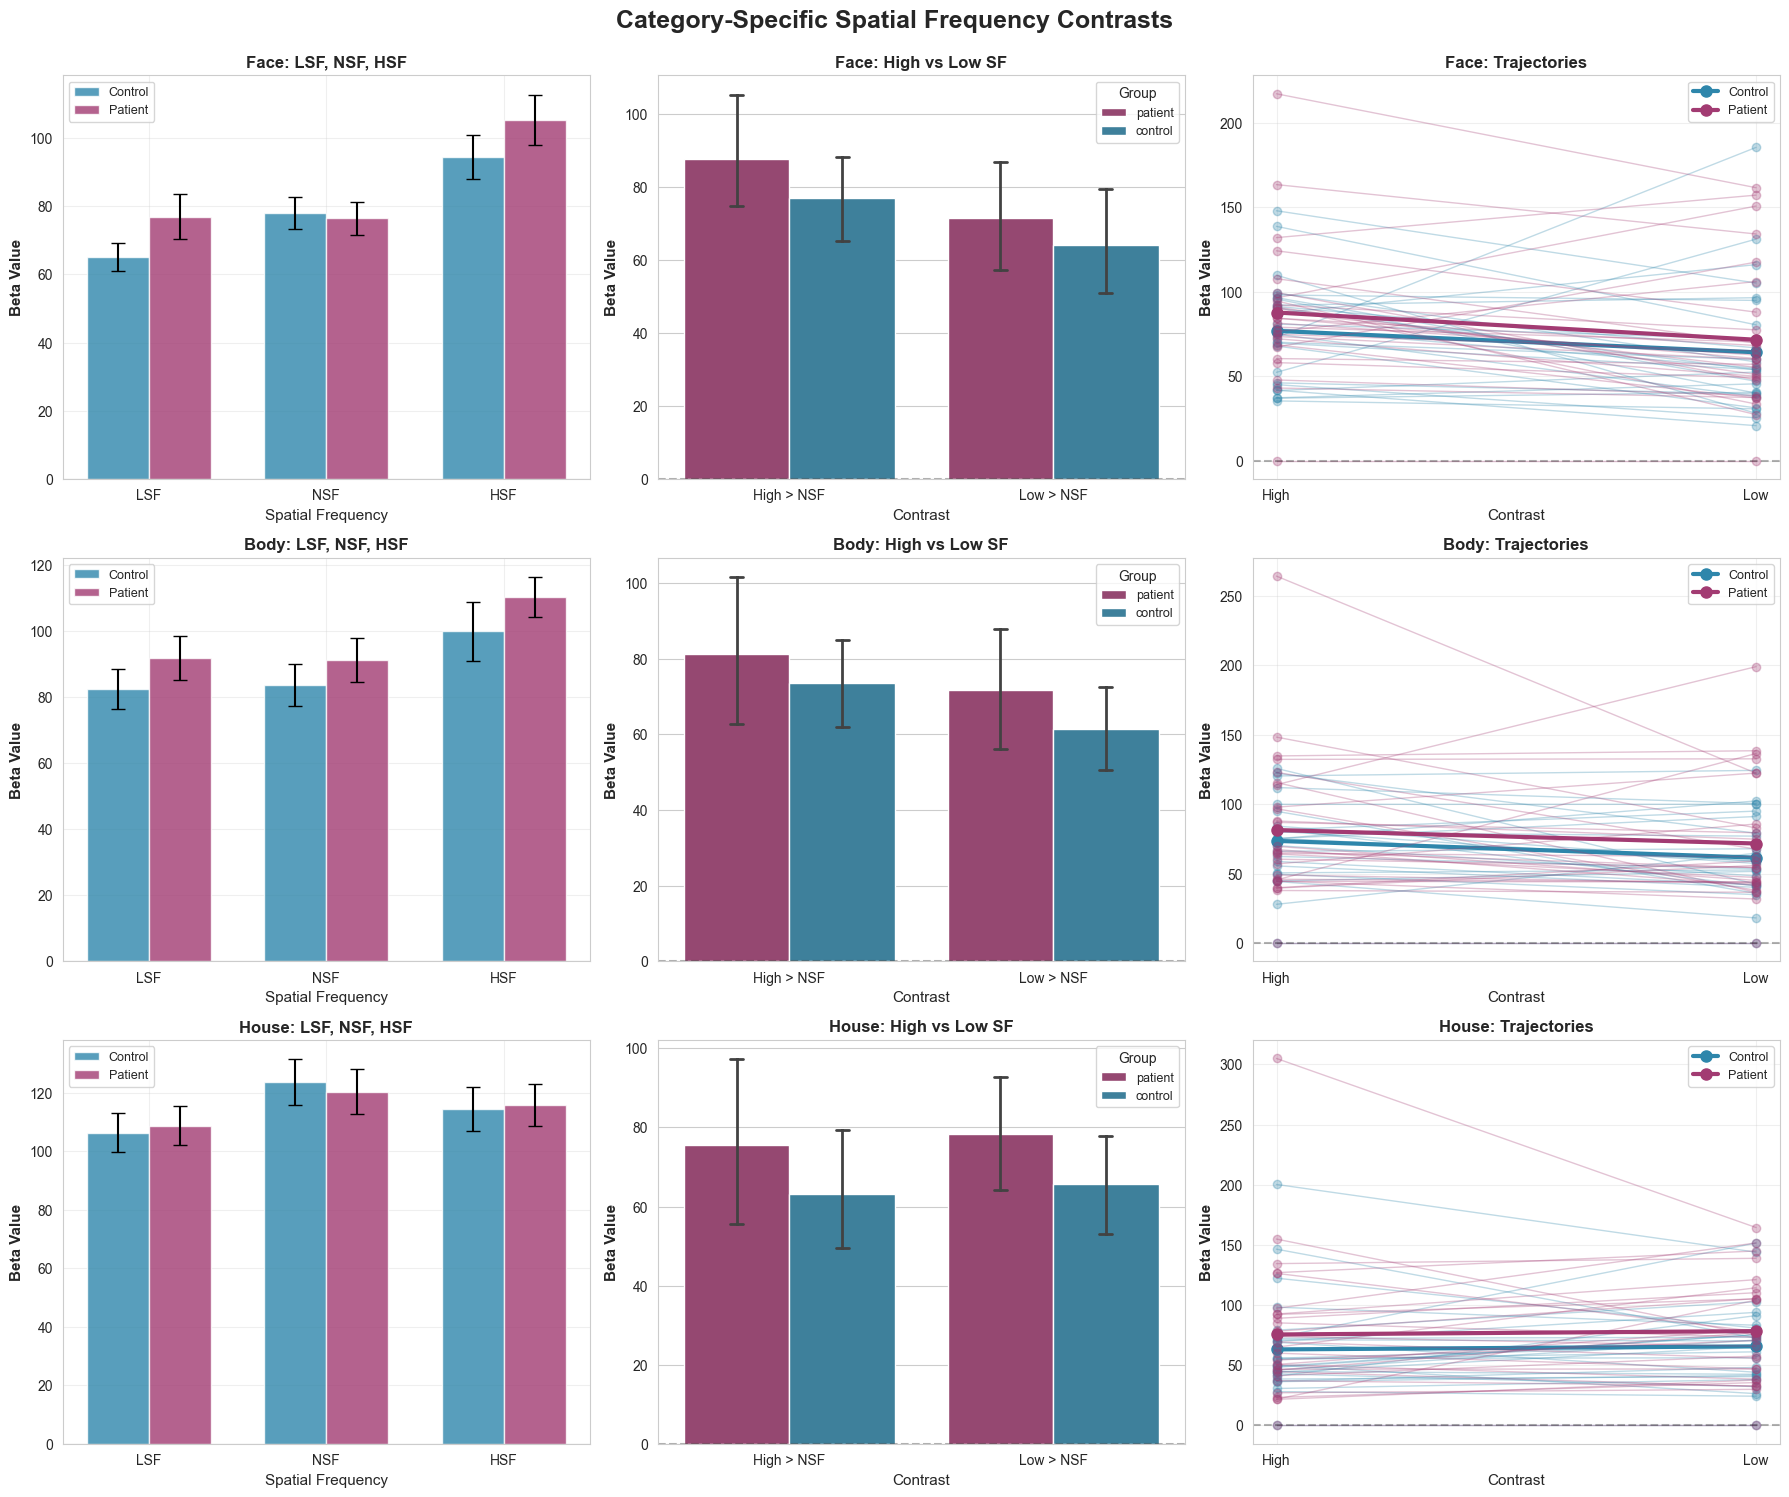

Effect size visualization saved as 'group_comparison_effect_sizes.png'


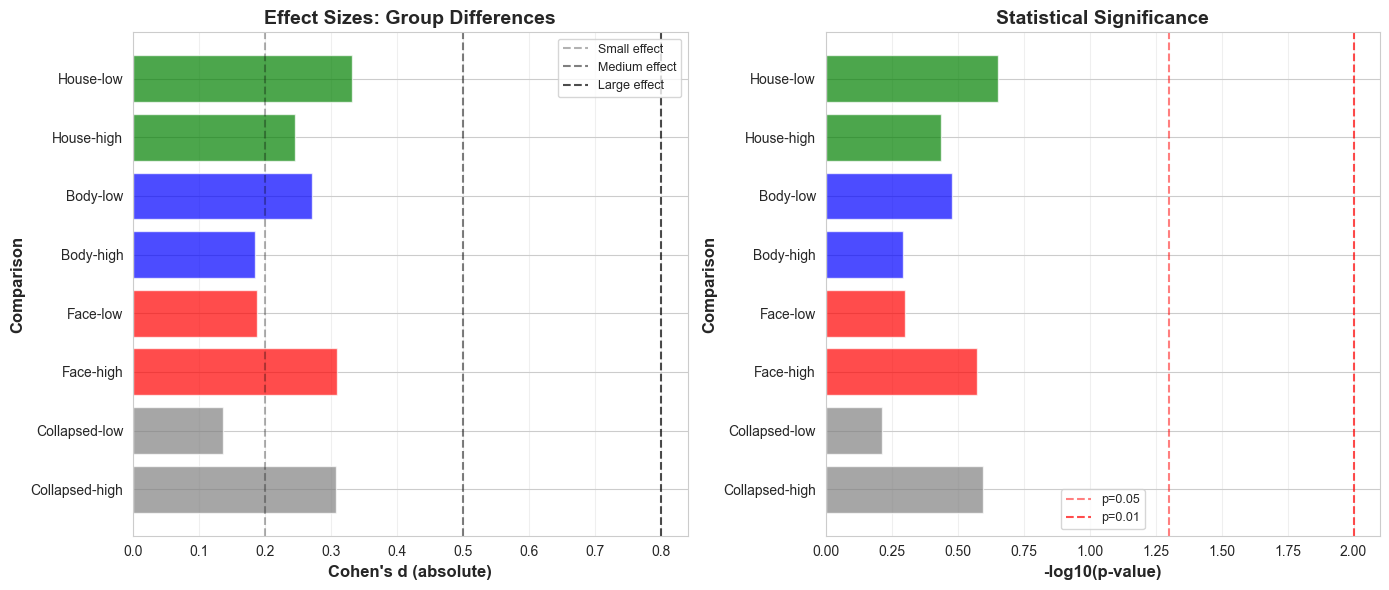


ANALYSIS COMPLETE!

Generated files:
  - all_contrasts_data.csv
  - group_comparisons_all_contrasts.csv
  - group_comparison_collapsed_contrasts.png
  - group_comparison_category_specific.png
  - group_comparison_effect_sizes.png


In [18]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import mixedlm
import statsmodels.api as sm

# -----------------------------
# Configuration
# -----------------------------

# Best extraction method (from previous analysis)
extraction_method = 'top_20pct_pos_beta_mean'

# Define group assignments based on subject list
patients = subjects[0:30]
controls = subjects[30:]

# Create group assignment dictionary
group_assignments = {}
for sub in patients:
    group_assignments[sub] = 'patient'
for sub in controls:
    group_assignments[sub] = 'control'

print(f"\nGroup assignments:")
print(f"  Patients: N={len(patients)}")
print(f"  Controls: N={len(controls)}")

# Define all contrasts to analyze
# Collapsed contrasts
collapsed_contrasts = ['LSF', 'NSF', 'HSF', 'high', 'low']

# Category-specific contrasts
categories = ['Face', 'Body', 'House']
category_contrasts = []
for cat in categories:
    category_contrasts.extend([
        f'{cat}-LSF', f'{cat}-NSF', f'{cat}-HSF', 
        f'{cat}-high', f'{cat}-low'
    ])

all_contrasts = collapsed_contrasts + category_contrasts

# -----------------------------
# Extract data for all contrasts
# -----------------------------

print("\n" + "="*80)
print("EXTRACTING DATA FOR ALL CONTRASTS")
print("="*80)

data_list = []

for sub in all_subject_results.keys():
    # Get group assignment
    if sub not in group_assignments:
        print(f"Warning: Subject {sub} not in group assignments, skipping")
        continue
    
    group = group_assignments[sub]
    
    # Extract values for each contrast
    for contrast_name in all_contrasts:
        # Check if data exists
        if contrast_name not in all_subject_results[sub]:
            continue
        
        value = all_subject_results[sub][contrast_name][extraction_method]
        
        # Skip if NaN
        if np.isnan(value):
            print(f"Warning: NaN value for subject {sub}, contrast {contrast_name}")
            continue
        
        # Determine contrast type and category
        if '-' in contrast_name:
            # Category-specific contrast
            parts = contrast_name.split('-')
            category = parts[0]
            sf_type = parts[1]
        else:
            # Collapsed contrast
            category = 'Collapsed'
            sf_type = contrast_name
        
        # Store data
        data_list.append({
            'subject': sub,
            'group': group,
            'contrast_name': contrast_name,
            'category': category,
            'sf_type': sf_type,
            'beta': value,
        })

# Create DataFrame
data_df = pd.DataFrame(data_list)

print(f"\nTotal observations: {len(data_df)}")
print(f"Subjects: {data_df['subject'].nunique()}")
print(f"Unique contrasts: {data_df['contrast_name'].nunique()}")

# Save the data
data_df.to_csv('all_contrasts_data.csv', index=False)
print("\nAll contrasts data saved to 'all_contrasts_data.csv'")

# Display sample data
print("\nSample data:")
print(data_df.head(10))

# -----------------------------
# Descriptive Statistics
# -----------------------------

print("\n" + "="*80)
print("DESCRIPTIVE STATISTICS")
print("="*80)

# Summary statistics by group, category, and SF type
summary_stats = data_df.groupby(['group', 'category', 'sf_type']).agg({
    'beta': ['mean', 'std', 'count']
}).round(4)

print("\nBeta values by Group, Category, and SF Type:")
print(summary_stats)

# -----------------------------
# Statistical Analysis for each SF comparison
# -----------------------------

print("\n" + "="*80)
print("STATISTICAL COMPARISONS: HIGH vs LOW SF")
print("="*80)

# Analyze 'high' and 'low' contrasts (differential effects)
comparison_results = []

for category in ['Collapsed'] + categories:
    # Get high and low contrast data for this category
    if category == 'Collapsed':
        high_contrast = 'high'
        low_contrast = 'low'
    else:
        high_contrast = f'{category}-high'
        low_contrast = f'{category}-low'
    
    # Extract data
    high_data = data_df[data_df['contrast_name'] == high_contrast]
    low_data = data_df[data_df['contrast_name'] == low_contrast]
    
    if len(high_data) == 0 or len(low_data) == 0:
        print(f"\nSkipping {category}: insufficient data")
        continue
    
    print(f"\n{'='*60}")
    print(f"CATEGORY: {category}")
    print('='*60)
    
    # Group comparisons for HIGH SF contrast
    print(f"\nHIGH SF Contrast ({high_contrast}):")
    control_high = high_data[high_data['group'] == 'control']['beta']
    patient_high = high_data[high_data['group'] == 'patient']['beta']
    
    if len(control_high) > 0 and len(patient_high) > 0:
        t_stat, p_val = stats.ttest_ind(control_high, patient_high)
        cohens_d = (np.mean(control_high) - np.mean(patient_high)) / np.sqrt(
            ((len(control_high)-1)*np.var(control_high, ddof=1) + 
             (len(patient_high)-1)*np.var(patient_high, ddof=1)) / 
            (len(control_high) + len(patient_high) - 2)
        )
        
        print(f"  Controls: M={np.mean(control_high):.4f}, SD={np.std(control_high, ddof=1):.4f}, N={len(control_high)}")
        print(f"  Patients: M={np.mean(patient_high):.4f}, SD={np.std(patient_high, ddof=1):.4f}, N={len(patient_high)}")
        print(f"  t({len(control_high)+len(patient_high)-2}) = {t_stat:.3f}, p = {p_val:.6f}")
        print(f"  Cohen's d = {cohens_d:.3f}")
        
        comparison_results.append({
            'category': category,
            'contrast': 'high',
            'control_mean': np.mean(control_high),
            'patient_mean': np.mean(patient_high),
            't_stat': t_stat,
            'p_value': p_val,
            'cohens_d': cohens_d
        })
    
    # Group comparisons for LOW SF contrast
    print(f"\nLOW SF Contrast ({low_contrast}):")
    control_low = low_data[low_data['group'] == 'control']['beta']
    patient_low = low_data[low_data['group'] == 'patient']['beta']
    
    if len(control_low) > 0 and len(patient_low) > 0:
        t_stat, p_val = stats.ttest_ind(control_low, patient_low)
        cohens_d = (np.mean(control_low) - np.mean(patient_low)) / np.sqrt(
            ((len(control_low)-1)*np.var(control_low, ddof=1) + 
             (len(patient_low)-1)*np.var(patient_low, ddof=1)) / 
            (len(control_low) + len(patient_low) - 2)
        )
        
        print(f"  Controls: M={np.mean(control_low):.4f}, SD={np.std(control_low, ddof=1):.4f}, N={len(control_low)}")
        print(f"  Patients: M={np.mean(patient_low):.4f}, SD={np.std(patient_low, ddof=1):.4f}, N={len(patient_low)}")
        print(f"  t({len(control_low)+len(patient_low)-2}) = {t_stat:.3f}, p = {p_val:.6f}")
        print(f"  Cohen's d = {cohens_d:.3f}")
        
        comparison_results.append({
            'category': category,
            'contrast': 'low',
            'control_mean': np.mean(control_low),
            'patient_mean': np.mean(patient_low),
            't_stat': t_stat,
            'p_value': p_val,
            'cohens_d': cohens_d
        })

# Save comparison results
comparison_df = pd.DataFrame(comparison_results)
comparison_df.to_csv('group_comparisons_all_contrasts.csv', index=False)
print("\n\nComparison results saved to 'group_comparisons_all_contrasts.csv'")

# -----------------------------
# Comprehensive Visualizations
# -----------------------------

print("\n" + "="*80)
print("CREATING COMPREHENSIVE VISUALIZATIONS")
print("="*80)

# Set style
sns.set_style("whitegrid")
colors = {'control': '#2E86AB', 'patient': '#A23B72'}

# -----------------------------
# Figure 1: Collapsed Contrasts (Main Effects)
# -----------------------------

fig1 = plt.figure(figsize=(18, 10))
gs1 = fig1.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Plot collapsed LSF, NSF, HSF
ax1 = fig1.add_subplot(gs1[0, :])
collapsed_sf_data = data_df[data_df['sf_type'].isin(['LSF', 'NSF', 'HSF']) & 
                             (data_df['category'] == 'Collapsed')]

# Bar plot with error bars
x_pos = np.arange(3)
width = 0.35
sf_order = ['LSF', 'NSF', 'HSF']

for i, group in enumerate(['control', 'patient']):
    group_data = collapsed_sf_data[collapsed_sf_data['group'] == group]
    means = [group_data[group_data['sf_type'] == sf]['beta'].mean() for sf in sf_order]
    sems = [group_data[group_data['sf_type'] == sf]['beta'].sem() for sf in sf_order]
    
    ax1.bar(x_pos + i*width, means, width, yerr=sems, 
            label=group.capitalize(), capsize=5, alpha=0.8, color=colors[group])

ax1.set_ylabel('Beta Value', fontsize=14, fontweight='bold')
ax1.set_xlabel('Spatial Frequency', fontsize=14, fontweight='bold')
ax1.set_title('Collapsed Across Categories: LSF, NSF, HSF', fontsize=16, fontweight='bold')
ax1.set_xticks(x_pos + width / 2)
ax1.set_xticklabels(sf_order, fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=1)

# Plot collapsed high and low contrasts
ax2 = fig1.add_subplot(gs1[1, 0])
collapsed_diff_data = data_df[data_df['sf_type'].isin(['high', 'low']) & 
                               (data_df['category'] == 'Collapsed')]

sns.barplot(data=collapsed_diff_data, x='sf_type', y='beta', hue='group', 
            ax=ax2, palette=colors, capsize=.1, errwidth=2)
ax2.set_ylabel('Beta Value', fontsize=12, fontweight='bold')
ax2.set_xlabel('Contrast', fontsize=12, fontweight='bold')
ax2.set_title('Collapsed: High vs Low SF', fontsize=14, fontweight='bold')
ax2.set_xticklabels(['High SF > NSF', 'Low SF > NSF'])
ax2.legend(title='Group')
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)

# Individual subject lines for high/low
ax3 = fig1.add_subplot(gs1[1, 1])
for group in ['control', 'patient']:
    group_data = collapsed_diff_data[collapsed_diff_data['group'] == group]
    for subject in group_data['subject'].unique():
        sub_data = group_data[group_data['subject'] == subject].sort_values('sf_type')
        if len(sub_data) == 2:
            ax3.plot(['High', 'Low'], sub_data['beta'].values, 
                    'o-', color=colors[group], alpha=0.3, linewidth=1)
    
    # Group means
    group_means = group_data.groupby('sf_type')['beta'].mean()
    if 'high' in group_means.index and 'low' in group_means.index:
        ax3.plot(['High', 'Low'], [group_means['high'], group_means['low']], 
                'o-', color=colors[group], linewidth=3, markersize=10, 
                label=group.capitalize())

ax3.set_ylabel('Beta Value', fontsize=12, fontweight='bold')
ax3.set_xlabel('Contrast', fontsize=12, fontweight='bold')
ax3.set_title('Individual Trajectories', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0, color='k', linestyle='--', alpha=0.3)

# Box plot comparison
ax4 = fig1.add_subplot(gs1[1, 2])
sns.boxplot(data=collapsed_diff_data, x='sf_type', y='beta', hue='group', 
            ax=ax4, palette=colors)
sns.stripplot(data=collapsed_diff_data, x='sf_type', y='beta', hue='group', 
              ax=ax4, dodge=True, alpha=0.4, size=4, palette=colors, legend=False)
ax4.set_ylabel('Beta Value', fontsize=12, fontweight='bold')
ax4.set_xlabel('Contrast', fontsize=12, fontweight='bold')
ax4.set_title('Distribution Comparison', fontsize=14, fontweight='bold')
ax4.set_xticklabels(['High SF > NSF', 'Low SF > NSF'])
ax4.legend(title='Group')
ax4.axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.savefig('group_comparison_collapsed_contrasts.png', dpi=300, bbox_inches='tight')
print("Collapsed contrasts visualization saved as 'group_comparison_collapsed_contrasts.png'")
plt.show()

# -----------------------------
# Figure 2: Category-Specific Contrasts
# -----------------------------

fig2, axes2 = plt.subplots(3, 3, figsize=(18, 15))
fig2.suptitle('Category-Specific Spatial Frequency Contrasts', 
              fontsize=18, fontweight='bold', y=0.995)

for cat_idx, category in enumerate(categories):
    cat_data = data_df[data_df['category'] == category]
    
    # Column 1: LSF, NSF, HSF for this category
    ax = axes2[cat_idx, 0]
    cat_sf_data = cat_data[cat_data['sf_type'].isin(['LSF', 'NSF', 'HSF'])]
    
    x_pos = np.arange(3)
    width = 0.35
    sf_order = ['LSF', 'NSF', 'HSF']
    
    for i, group in enumerate(['control', 'patient']):
        group_data = cat_sf_data[cat_sf_data['group'] == group]
        means = [group_data[group_data['sf_type'] == sf]['beta'].mean() for sf in sf_order]
        sems = [group_data[group_data['sf_type'] == sf]['beta'].sem() for sf in sf_order]
        
        ax.bar(x_pos + i*width, means, width, yerr=sems, 
               label=group.capitalize(), capsize=5, alpha=0.8, color=colors[group])
    
    ax.set_ylabel('Beta Value', fontsize=11, fontweight='bold')
    ax.set_xlabel('Spatial Frequency', fontsize=11)
    ax.set_title(f'{category}: LSF, NSF, HSF', fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos + width / 2)
    ax.set_xticklabels(sf_order)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
    
    # Column 2: High and Low contrasts bar plot
    ax = axes2[cat_idx, 1]
    cat_diff_data = cat_data[cat_data['sf_type'].isin(['high', 'low'])]
    
    sns.barplot(data=cat_diff_data, x='sf_type', y='beta', hue='group', 
                ax=ax, palette=colors, capsize=.1, errwidth=2)
    ax.set_ylabel('Beta Value', fontsize=11, fontweight='bold')
    ax.set_xlabel('Contrast', fontsize=11)
    ax.set_title(f'{category}: High vs Low SF', fontsize=12, fontweight='bold')
    ax.set_xticklabels(['High > NSF', 'Low > NSF'])
    ax.legend(title='Group', fontsize=9)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    # Column 3: Individual trajectories
    ax = axes2[cat_idx, 2]
    for group in ['control', 'patient']:
        group_data = cat_diff_data[cat_diff_data['group'] == group]
        for subject in group_data['subject'].unique():
            sub_data = group_data[group_data['subject'] == subject].sort_values('sf_type')
            if len(sub_data) == 2:
                ax.plot(['High', 'Low'], sub_data['beta'].values, 
                       'o-', color=colors[group], alpha=0.3, linewidth=1)
        
        # Group means
        group_means = group_data.groupby('sf_type')['beta'].mean()
        if 'high' in group_means.index and 'low' in group_means.index:
            ax.plot(['High', 'Low'], [group_means['high'], group_means['low']], 
                   'o-', color=colors[group], linewidth=3, markersize=8, 
                   label=group.capitalize())
    
    ax.set_ylabel('Beta Value', fontsize=11, fontweight='bold')
    ax.set_xlabel('Contrast', fontsize=11)
    ax.set_title(f'{category}: Trajectories', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('group_comparison_category_specific.png', dpi=300, bbox_inches='tight')
print("Category-specific visualization saved as 'group_comparison_category_specific.png'")
plt.show()

# -----------------------------
# Figure 3: Effect Size Summary
# -----------------------------

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Cohen's d for all comparisons
ax = axes3[0]
comparison_df['abs_cohens_d'] = np.abs(comparison_df['cohens_d'])
comparison_df['comparison'] = comparison_df['category'] + '-' + comparison_df['contrast']

colors_map = {'Collapsed': 'gray', 'Face': 'red', 'Body': 'blue', 'House': 'green'}
comparison_df['color'] = comparison_df['category'].map(colors_map)

ax.barh(comparison_df['comparison'], comparison_df['abs_cohens_d'], 
        color=comparison_df['color'], alpha=0.7)
ax.set_xlabel("Cohen's d (absolute)", fontsize=12, fontweight='bold')
ax.set_ylabel('Comparison', fontsize=12, fontweight='bold')
ax.set_title("Effect Sizes: Group Differences", fontsize=14, fontweight='bold')
ax.axvline(x=0.2, color='k', linestyle='--', alpha=0.3, label='Small effect')
ax.axvline(x=0.5, color='k', linestyle='--', alpha=0.5, label='Medium effect')
ax.axvline(x=0.8, color='k', linestyle='--', alpha=0.7, label='Large effect')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

# Plot 2: P-values
ax = axes3[1]
comparison_df['neg_log_p'] = -np.log10(comparison_df['p_value'])

ax.barh(comparison_df['comparison'], comparison_df['neg_log_p'], 
        color=comparison_df['color'], alpha=0.7)
ax.set_xlabel('-log10(p-value)', fontsize=12, fontweight='bold')
ax.set_ylabel('Comparison', fontsize=12, fontweight='bold')
ax.set_title("Statistical Significance", fontsize=14, fontweight='bold')
ax.axvline(x=-np.log10(0.05), color='r', linestyle='--', alpha=0.5, label='p=0.05')
ax.axvline(x=-np.log10(0.01), color='r', linestyle='--', alpha=0.7, label='p=0.01')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('group_comparison_effect_sizes.png', dpi=300, bbox_inches='tight')
print("Effect size visualization saved as 'group_comparison_effect_sizes.png'")
plt.show()

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("\nGenerated files:")
print("  - all_contrasts_data.csv")
print("  - group_comparisons_all_contrasts.csv")
print("  - group_comparison_collapsed_contrasts.png")
print("  - group_comparison_category_specific.png")
print("  - group_comparison_effect_sizes.png")